In [272]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [273]:
df = pd.read_csv("train.csv")

In [274]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [275]:
df.shape

(200, 5)

In [276]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [277]:
df.duplicated().sum()

np.int64(0)

In [278]:
print(df['Gender'].dtype)

object


In [279]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

<Axes: >

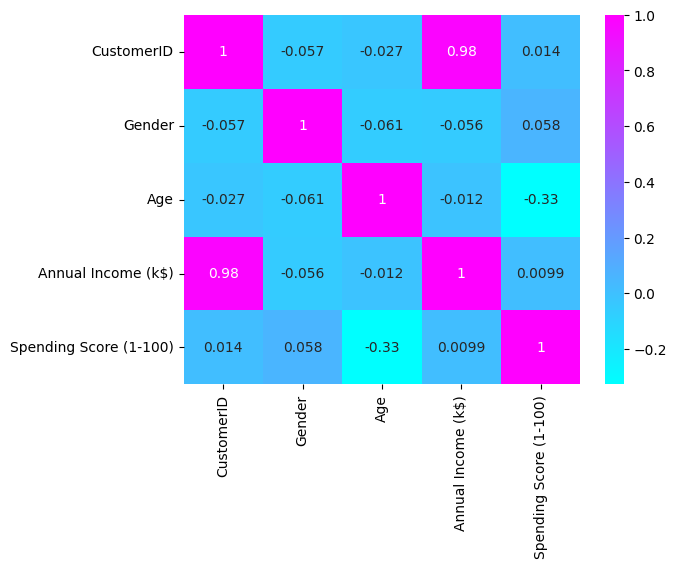

In [280]:
corr = df.corr()
sns.heatmap(corr, annot = True, cmap = "cool")

In [281]:
corr['Annual Income (k$)'].sort_values(ascending=False)

Annual Income (k$)        1.000000
CustomerID                0.977548
Spending Score (1-100)    0.009903
Age                      -0.012398
Gender                   -0.056410
Name: Annual Income (k$), dtype: float64

In [282]:
corr['Age'].sort_values(ascending=False)

Age                       1.000000
Annual Income (k$)       -0.012398
CustomerID               -0.026763
Gender                   -0.060867
Spending Score (1-100)   -0.327227
Name: Age, dtype: float64

In [283]:
corr['Spending Score (1-100)'].sort_values(ascending=False)

Spending Score (1-100)    1.000000
Gender                    0.058109
CustomerID                0.013835
Annual Income (k$)        0.009903
Age                      -0.327227
Name: Spending Score (1-100), dtype: float64

In [284]:
df = df.drop("CustomerID", axis = 1)

In [285]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [286]:
df1 = df[["Annual Income (k$)", "Spending Score (1-100)"]]
df1.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

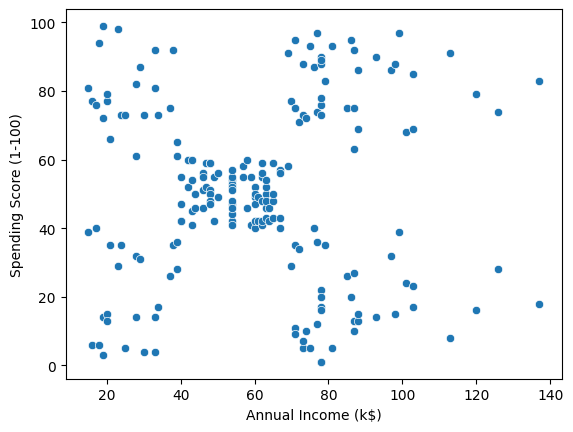

In [287]:
sns.scatterplot(x = df1['Annual Income (k$)'], y = df1['Spending Score (1-100)'])

In [288]:
inertia = []
K_range = range(1,15)
for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

In [289]:
inertia

[799.9999999999999,
 597.9472937932279,
 494.8037500130457,
 395.3920903479797,
 351.74320617119116,
 277.38974019851906,
 251.15484911190174,
 211.98576294959307,
 185.72807688711416,
 152.02983429775688,
 137.49737186521224,
 130.34015200838118,
 119.94131042961752,
 115.66721679423239]

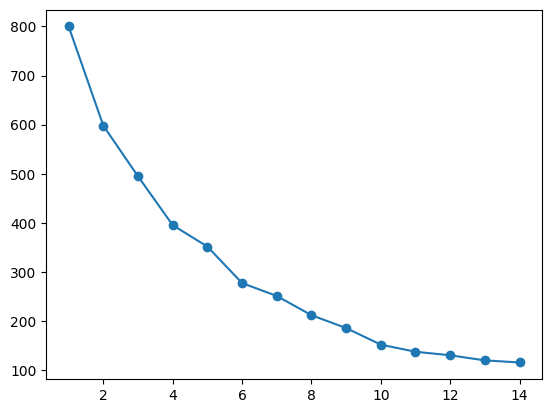

In [290]:
plt.plot(K_range, inertia, marker = 'o')

In [291]:
#choose k with highest silhouette score
for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels) #since at least 2 clusters are required to evaluate how well-separated the clusters are (1,15) is not used
    print(k, score)

2 0.2776035125578272
3 0.2576199805135528
4 0.29010917402310876
5 0.27191023466188324
6 0.3347543475669217
7 0.3457397879257699
8 0.37276475942129284
9 0.38761462444422967
10 0.42076374869477745
11 0.42750694213514717
12 0.42570130766571246
13 0.42399362401364354
14 0.41281846954539747


In [292]:
kmeans_final = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_scaled)
# df1 = df1.copy()
df['cluster']=cluster_labels


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

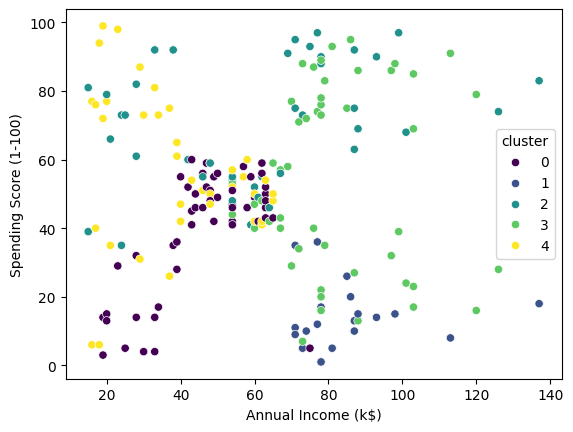

In [293]:
sns.scatterplot(x=df1['Annual Income (k$)'],
                y=df1['Spending Score (1-100)'],
                hue=df['cluster'],
                palette='viridis')

In [294]:
df['cluster'].value_counts()

cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64

In [295]:
joblib.dump(kmeans_final, 'model.pkl')
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [296]:
df.groupby('cluster')[df1.columns].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,46.098039,39.313725
1,85.150000,14.050000
2,60.904762,70.238095
3,82.122449,54.448980
4,38.842105,56.210526


In [297]:
print(scaler.feature_names_in_)

['Gender' 'Age' 'Annual Income (k$)' 'Spending Score (1-100)']
